<a href="https://colab.research.google.com/github/abhi07dev/AIML-proj/blob/main/covid_data_analytics_p1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
import sqlite3

In [2]:
file_path = r"/content/covid_19_india.csv"
df = pd.read_csv(file_path)

In [3]:
print("Initial dataset shape:", df.shape)

Initial dataset shape: (18110, 9)


In [4]:
df_cleaned = df.drop_duplicates()

df_cleaned = df_cleaned.dropna()

In [5]:
df_cleaned.columns = df_cleaned.columns.str.strip().str.lower().str.replace(' ', '_')

In [6]:
cleaned_file_path = 'covid_19_india_cleaned.csv'

df_cleaned.to_csv(cleaned_file_path, index=False)

print("Cleaned dataset shape:", df_cleaned.shape)
print(f"Cleaned data saved to {cleaned_file_path}")

Cleaned dataset shape: (18110, 9)
Cleaned data saved to covid_19_india_cleaned.csv


In [7]:
file_path = 'covid_19_india_cleaned.csv'
df = pd.read_csv(file_path)

In [8]:
print("Initial dataset shape:", df.shape)

conn = sqlite3.connect('covid_data.db')
cursor = conn.cursor()

Initial dataset shape: (18110, 9)


In [ ]:
df.to_sql('covid_data', conn, index=False, if_exists='replace')

df_cleaned = pd.read_sql("""
    SELECT DISTINCT * FROM covid_data
""", conn)

In [9]:
df_cleaned = df_cleaned.dropna()

df_cleaned.columns = df_cleaned.columns.str.strip().str.lower().str.replace(' ', '_')

In [10]:
df_cleaned.to_sql('covid_data_cleaned', conn, index=False, if_exists='replace')

cleaned_file_path = 'covid_19_india_cleaned.csv'
df_cleaned.to_csv(cleaned_file_path, index=False)

print("Cleaned dataset shape:", df_cleaned.shape)
print(f"Cleaned data saved to {cleaned_file_path} and stored in database")

Cleaned dataset shape: (18110, 9)
Cleaned data saved to covid_19_india_cleaned.csv and stored in database


In [11]:
data=pd.read_csv("covid_19_india_cleaned.csv")
df=pd.DataFrame(data)
df

,sno,date,time,state/unionterritory,confirmedindiannational,confirmedforeignnational,cured,deaths,confirmed
0,1,2020-01-30,6:00 PM,Kerala,1,0,0,0,1
1,2,2020-01-31,6:00 PM,Kerala,1,0,0,0,1
2,3,2020-02-01,6:00 PM,Kerala,2,0,0,0,2
3,4,2020-02-02,6:00 PM,Kerala,3,0,0,0,3
4,5,2020-02-03,6:00 PM,Kerala,3,0,0,0,3
...,...,...,...,...,...,...,...,...,...
18105,18106,2021-08-11,8:00 AM,Telangana,-,-,638410,3831,650353
18106,18107,2021-08-11,8:00 AM,Tripura,-,-,77811,773,80660
18107,18108,2021-08-11,8:00 AM,Uttarakhand,-,-,334650,7368,342462
18108,18109,2021-08-11,8:00 AM,Uttar Pradesh,-,-,1685492,22775,1708812


In [15]:
df['confirmed']=df['confirmed']*1
df

,sno,date,time,state/unionterritory,confirmedindiannational,confirmedforeignnational,cured,deaths,confirmed
0,1,2020-01-30,6:00 PM,Kerala,1,0,0,0,10000000000000
1,2,2020-01-31,6:00 PM,Kerala,1,0,0,0,10000000000000
2,3,2020-02-01,6:00 PM,Kerala,2,0,0,0,20000000000000
3,4,2020-02-02,6:00 PM,Kerala,3,0,0,0,30000000000000
4,5,2020-02-03,6:00 PM,Kerala,3,0,0,0,30000000000000
...,...,...,...,...,...,...,...,...,...
18105,18106,2021-08-11,8:00 AM,Telangana,-,-,638410,3831,6503530000000000000
18106,18107,2021-08-11,8:00 AM,Tripura,-,-,77811,773,806600000000000000
18107,18108,2021-08-11,8:00 AM,Uttarakhand,-,-,334650,7368,3424620000000000000
18108,18109,2021-08-11,8:00 AM,Uttar Pradesh,-,-,1685492,22775,-1358624073709551616


In [18]:
data=pd.read_csv("covid_19_india_cleaned.csv")
df=pd.DataFrame(data)

# Convert 'deaths' column to numeric, coercing errors to NaN
df['deaths'] = pd.to_numeric(df['deaths'], errors='coerce')

# Drop rows where 'deaths' became NaN after conversion
df = df.dropna(subset=['deaths'])


lb = 0
ub = df['deaths'].max()

df_cl1=df[(df['deaths']>lb) & (df["deaths"]<ub)]
df_cl1

,sno,date,time,state/unionterritory,confirmedindiannational,confirmedforeignnational,cured,deaths,confirmed
132,133,2020-03-13,6:00 PM,Karnataka,6,0,0,1,6
135,136,2020-03-14,6:00 PM,Delhi,7,0,1,1,7
145,146,2020-03-14,6:00 PM,Karnataka,6,0,0,1,6
149,150,2020-03-15,6:00 PM,Delhi,7,0,2,1,7
151,152,2020-03-15,6:00 PM,Karnataka,6,0,0,1,6
...,...,...,...,...,...,...,...,...,...
18105,18106,2021-08-11,8:00 AM,Telangana,-,-,638410,3831,650353
18106,18107,2021-08-11,8:00 AM,Tripura,-,-,77811,773,80660
18107,18108,2021-08-11,8:00 AM,Uttarakhand,-,-,334650,7368,342462
18108,18109,2021-08-11,8:00 AM,Uttar Pradesh,-,-,1685492,22775,1708812


count     18110.000000
mean       4052.402264
std       10919.076411
min           0.000000
25%          32.000000
50%         588.000000
75%        3643.750000
max      134201.000000
Name: deaths, dtype: float64


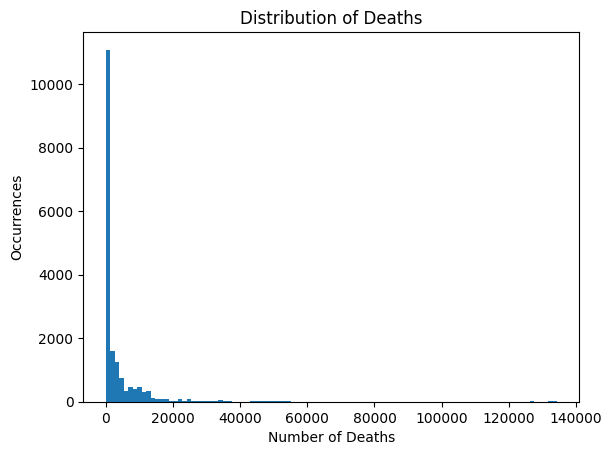

In [20]:

print(data['deaths'].describe())
plt.hist(data['deaths'], 100, range=(0, data['deaths'].max()), label='deaths')
plt.xlabel("Number of Deaths")
plt.ylabel("Occurrences")
plt.title("Distribution of Deaths")
plt.show()

Initial dataset shape: (18110, 9)
Cleaned dataset shape: (18110, 9)
Cleaned data saved to covid_19_india_cleaned.csv
Columns in cleaned dataset: Index(['sno', 'date', 'time', 'state_unionterritory',
       'confirmedindiannational', 'confirmedforeignnational', 'cured',
       'deaths', 'confirmed'],
      dtype='object')


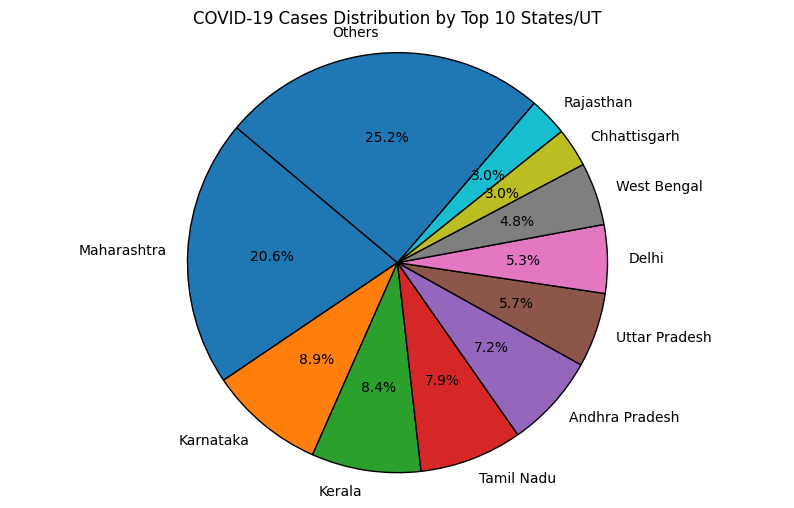

In [23]:
file_path = 'covid_19_india_cleaned.csv'
df = pd.read_csv(file_path)

print("Initial dataset shape:", df.shape)

conn = sqlite3.connect('covid_data.db')
cursor = conn.cursor()

df.to_sql('covid_data', conn, index=False, if_exists='replace')


df_cleaned = pd.read_sql("""
    SELECT DISTINCT * FROM covid_data
""", conn)


df_cleaned = df_cleaned.dropna()


df_cleaned.columns = df_cleaned.columns.str.strip().str.lower().str.replace('[^a-zA-Z0-9_]', '_', regex=True)


df_cleaned.to_sql('covid_data_cleaned', conn, index=False, if_exists='replace')


cleaned_file_path = 'covid_19_india_cleaned.csv'
df_cleaned.to_csv(cleaned_file_path, index=False)

print("Cleaned dataset shape:", df_cleaned.shape)
print(f"Cleaned data saved to {cleaned_file_path}")


print("Columns in cleaned dataset:", df_cleaned.columns)


if 'state_unionterritory' in df_cleaned.columns and 'confirmed' in df_cleaned.columns:
    state_wise_cases = df_cleaned.groupby('state_unionterritory')['confirmed'].sum()


    top_states = state_wise_cases.sort_values(ascending=False).head(10)
    other_cases = state_wise_cases.sum() - top_states.sum()

    labels = list(top_states.index) + ['Others']
    sizes = list(top_states.values) + [other_cases]

    plt.figure(figsize=(10, 6))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'black'})
    plt.title("COVID-19 Cases Distribution by Top 10 States/UT")
    plt.axis('equal')
    plt.show()
else:
    print("Error: Required columns not found in the dataset.")


conn.close()

Top 10 States/UTs by Cured Cases :
                        cured  deaths
state_unionterritory                 
Maharashtra***        6000911  130753
Kerala                3396184   18004
Karnataka             2861499   36848
Karanataka            2821491   36197
Tamil Nadu            2524400   34367
Andhra Pradesh        1952736   13564
Uttar Pradesh         1685492   22775
West Bengal           1506532   18252
Delhi                 1411280   25068
Chhattisgarh           988189   13544


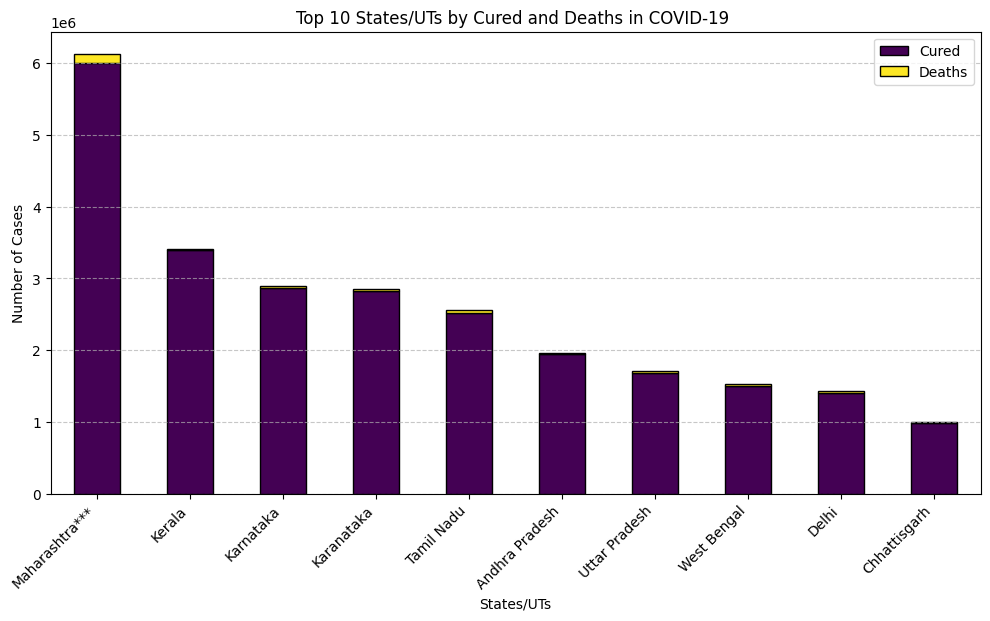

In [24]:

df = pd.read_csv("covid_19_india_cleaned.csv")


df.columns = df.columns.str.strip().str.lower().str.replace('[^a-zA-Z0-9_]', '_', regex=True)


latest_data = df.groupby('state_unionterritory').last()[['cured', 'deaths']]


latest_data = latest_data[latest_data.index != 'Maharashtra']


top_states = latest_data.sort_values(by='cured', ascending=False).head(10)

print("Top 10 States/UTs by Cured Cases :")
print(top_states)


plt.figure(figsize=(12, 6))
top_states.plot(kind='bar', stacked=True, colormap='viridis', edgecolor='black', ax=plt.gca())


plt.xlabel("States/UTs")
plt.ylabel("Number of Cases")
plt.title("Top 10 States/UTs by Cured and Deaths in COVID-19 ")
plt.xticks(rotation=45, ha='right')
plt.legend(["Cured", "Deaths"])
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.show()

/tmp/ipykernel_9500/3550262287.py:5: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'], dayfirst=True)


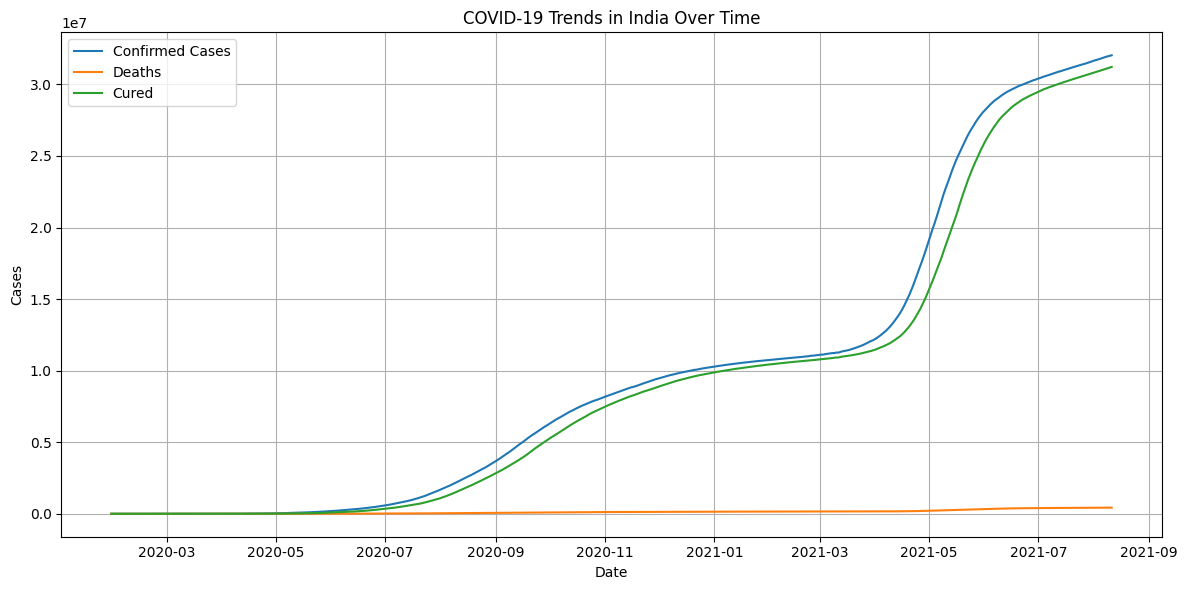

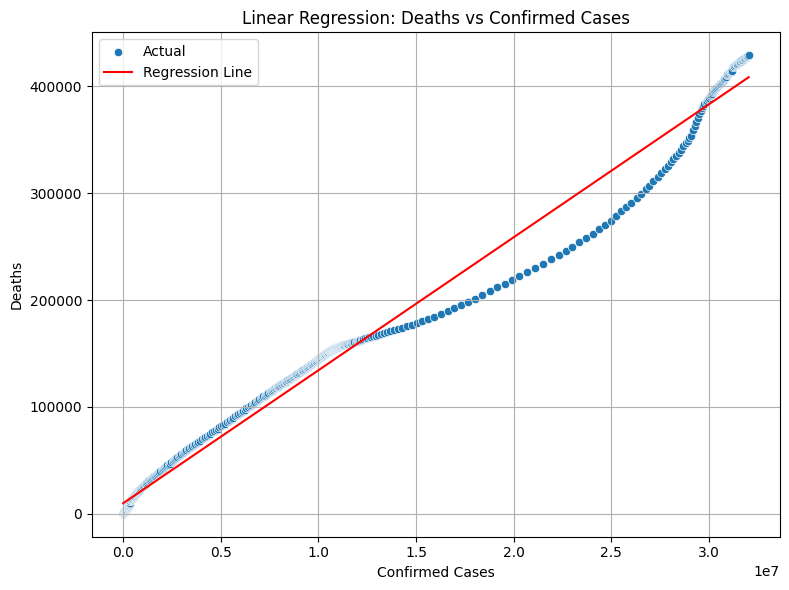

Coefficient: 0.012447647150269124
Intercept: 9872.200584967024
R-squared: 0.9870858473426565
Mean Squared Error: 210032775.77732143


In [25]:

df = pd.read_csv("covid_19_india_cleaned.csv")


df['date'] = pd.to_datetime(df['date'], dayfirst=True)


df['confirmedindiannational'] = pd.to_numeric(df['confirmedindiannational'], errors='coerce')
df['confirmedforeignnational'] = pd.to_numeric(df['confirmedforeignnational'], errors='coerce')


df[['confirmedindiannational', 'confirmedforeignnational']] = df[['confirmedindiannational', 'confirmedforeignnational']].fillna(0)

daily_data = df.groupby('date')[['confirmed', 'cured', 'deaths']].sum().reset_index()


plt.figure(figsize=(12, 6))
plt.plot(daily_data['date'], daily_data['confirmed'], label='Confirmed Cases')
plt.plot(daily_data['date'], daily_data['deaths'], label='Deaths')
plt.plot(daily_data['date'], daily_data['cured'], label='Cured')
plt.title('COVID-19 Trends in India Over Time')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

X = daily_data[['confirmed']]
y = daily_data['deaths']

model = LinearRegression()
model.fit(X, y)


y_pred = model.predict(X)


plt.figure(figsize=(8, 6))
sns.scatterplot(x='confirmed', y='deaths', data=daily_data, label='Actual')
plt.plot(daily_data['confirmed'], y_pred, color='red', label='Regression Line')
plt.title('Linear Regression: Deaths vs Confirmed Cases')
plt.xlabel('Confirmed Cases')
plt.ylabel('Deaths')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print model evaluation
print(f"Coefficient: {model.coef_[0]}")
print(f"Intercept: {model.intercept_}")
print(f"R-squared: {r2_score(y, y_pred)}")
print(f"Mean Squared Error: {mean_squared_error(y, y_pred)}")

/tmp/ipykernel_9500/3233816116.py:10: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'], dayfirst=True)


Confusion Matrix:
[[62  0]
 [ 0 50]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        62
           1       1.00      1.00      1.00        50

    accuracy                           1.00       112
   macro avg       1.00      1.00      1.00       112
weighted avg       1.00      1.00      1.00       112


Accuracy: 1.0


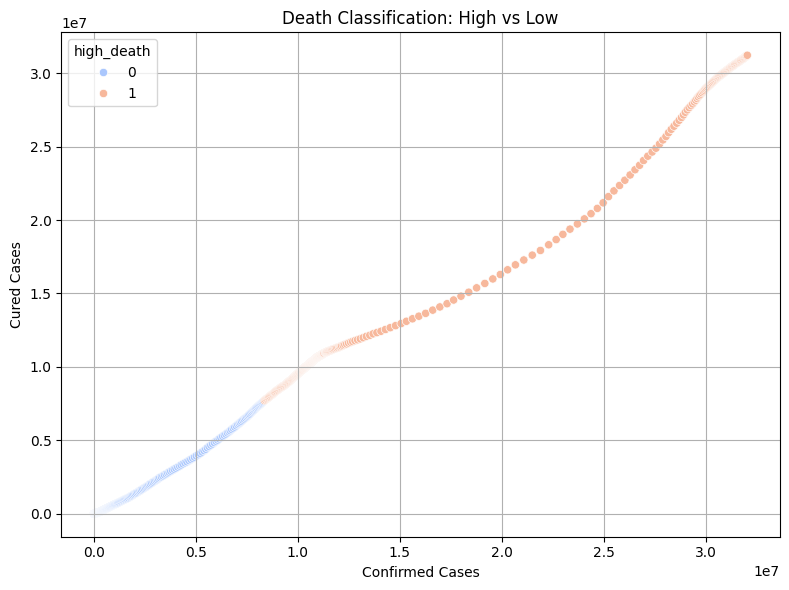

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


df = pd.read_csv("covid_19_india_cleaned.csv")


df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df['confirmedindiannational'] = pd.to_numeric(df['confirmedindiannational'], errors='coerce')
df['confirmedforeignnational'] = pd.to_numeric(df['confirmedforeignnational'], errors='coerce')

df[['confirmedindiannational', 'confirmedforeignnational']] = df[
    ['confirmedindiannational', 'confirmedforeignnational']
].fillna(0)


daily_data = df.groupby('date')[['confirmed', 'cured', 'deaths']].sum().reset_index()


median_deaths = daily_data['deaths'].median()
daily_data['high_death'] = (daily_data['deaths'] > median_deaths).astype(int)

X = daily_data[['confirmed', 'cured']]
y = daily_data['high_death']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print(f"\nAccuracy: {accuracy_score(y_test, y_pred)}")


plt.figure(figsize=(8,6))
sns.scatterplot(
    data=daily_data,
    x='confirmed',
    y='cured',
    hue='high_death',
    palette='coolwarm'
)

plt.title('Death Classification: High vs Low')
plt.xlabel('Confirmed Cases')
plt.ylabel('Cured Cases')
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_9500/2915480912.py:11: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'], dayfirst=True)


Explained Variance Ratio (PCA): [0.9987498 0.0012502]

Confusion Matrix:
[[ 6 56]
 [ 0 50]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.10      0.18        62
           1       0.47      1.00      0.64        50

    accuracy                           0.50       112
   macro avg       0.74      0.55      0.41       112
weighted avg       0.76      0.50      0.38       112


Accuracy: 0.5


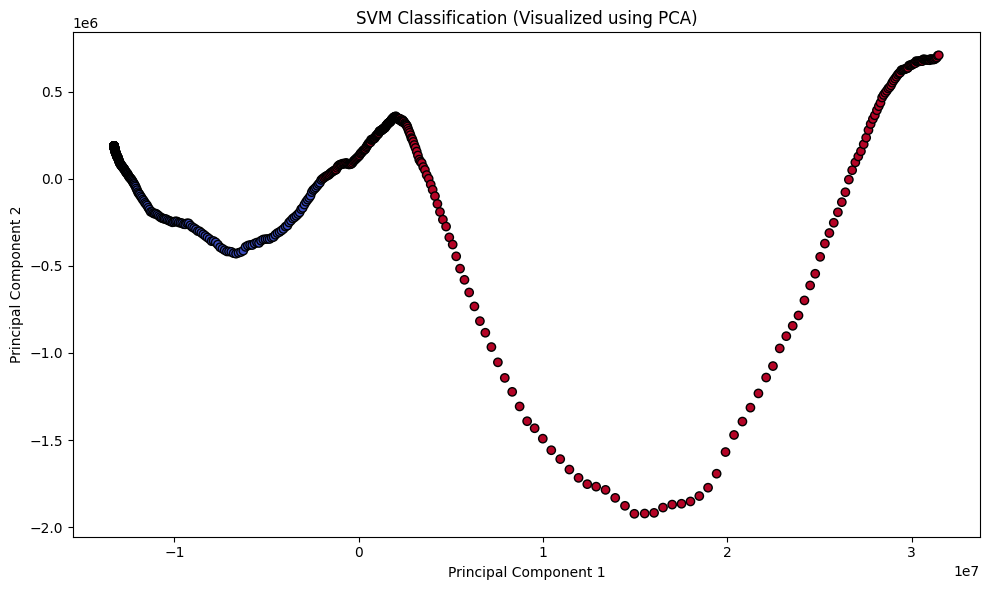

In [27]:
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df = pd.read_csv("covid_19_india_cleaned.csv")
df.columns = df.columns.str.lower().str.strip()

df['date'] = pd.to_datetime(df['date'], dayfirst=True)

df['confirmedindiannational'] = pd.to_numeric(df['confirmedindiannational'], errors='coerce').fillna(0)
df['confirmedforeignnational'] = pd.to_numeric(df['confirmedforeignnational'], errors='coerce').fillna(0)

daily_data = df.groupby('date')[['confirmed', 'cured', 'deaths', 'confirmedindiannational', 'confirmedforeignnational']].sum().reset_index()

median_deaths = daily_data['deaths'].median()
daily_data['high_death'] = (daily_data['deaths'] > median_deaths).astype(int)

features = ['confirmed', 'cured', 'confirmedindiannational', 'confirmedforeignnational']
X = daily_data[features]
y = daily_data['high_death']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print("Explained Variance Ratio (PCA):", pca.explained_variance_ratio_)

svm_model = SVC(kernel='rbf', C=1.0, gamma='auto')
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"\nAccuracy: {accuracy_score(y_test, y_pred)}")

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
plt.title("SVM Classification (Visualized using PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

Confusion Matrix:
 [[42  0]
 [ 0 48]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       1.00      1.00      1.00        48

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90


Accuracy: 1.0


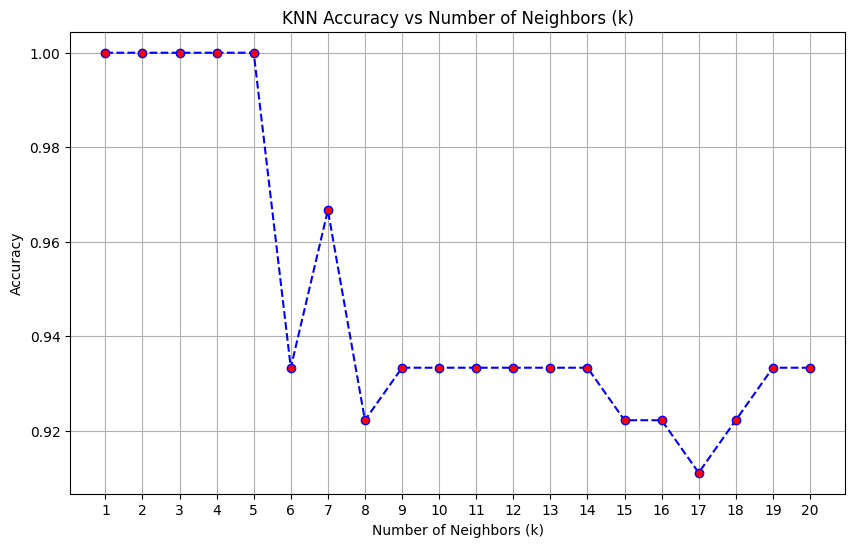

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

df = pd.read_csv("covid_19_india_cleaned.csv")

df_clean = df.dropna()

numeric_cols = ['confirmedindiannational', 'confirmedforeignnational', 'cured', 'deaths']
df_clean[numeric_cols] = df_clean[numeric_cols].apply(pd.to_numeric, errors='coerce')

df_clean = df_clean.dropna(subset=numeric_cols + ['confirmed'])

X = df_clean[numeric_cols]
median_confirmed = df_clean['confirmed'].median()
y = (df_clean['confirmed'] > median_confirmed).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)


y_pred = knn.predict(X_test_scaled)

conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

class_report = classification_report(y_test, y_pred)
print("\nClassification Report:\n", class_report)

accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)


k_range = range(1, 21)
accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_k = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_k)
    accuracies.append(acc)


plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracies, color='blue', linestyle='dashed', marker='o', markerfacecolor='red')
plt.title('KNN Accuracy vs Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.xticks(k_range)
plt.show()
